# Performance Benchmarking: Pandas vs Polars vs PySpark

This notebook evaluates the **load times**, **memory usage**, and **group-by aggregation performance** of the popular data processing libraries: **Pandas**, **Polars**, and **PySpark**.

## 1. Setup

In [13]:
import pandas as pd
import polars as pl
from pyspark.sql import SparkSession
import numpy as np
import time
import matplotlib.pyplot as plt
import os

spark = SparkSession.builder.master("local[*]").getOrCreate()

## 2. Data Loading Benchmark

I benchmarked data loading using the classic **Iris dataset** in two formats:

- **CSV**: Original Iris dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/53/iris)
- **Parquet**: Converted Parquet version from [Agents For Data](https://www.agentsfordata.com/parquet/sample)

In [14]:
results = []

start = time.perf_counter()
df_pd_csv = pd.read_csv('./iris/iris.data', names=['sepal_length','sepal_width','petal_length','petal_width','species'])
results.append(("Pandas", "CSV", time.perf_counter() - start))
start = time.perf_counter()
df_pd_parquet = pd.read_parquet('iris.parquet')
results.append(("Pandas", "Parquet", time.perf_counter() - start))


start = time.perf_counter()
df_pl_csv = pl.read_csv('./iris/iris.data', new_columns=['sepal_length','sepal_width','petal_length','petal_width','species'])
results.append(("Polars", "CSV", time.perf_counter() - start))
start = time.perf_counter()
df_pl_parquet = pl.read_parquet('iris.parquet')
results.append(("Polars", "Parquet", time.perf_counter() - start))

start = time.perf_counter()
#because of the enviroment, can't do it like this
# spark.read.csv(
#     './iris/iris.data',
#     schema="""
#         sepal_length DOUBLE,
#         sepal_width DOUBLE,
#         petal_length DOUBLE,
#         petal_width DOUBLE,
#         species STRING
#     """,
#     header=False
# ).count()
df_spark_csv = spark.createDataFrame(
    pd.read_csv("./iris/iris.data",names=["sepal_length","sepal_width","petal_length","petal_width","species"])
)
df_spark_csv.count()
results.append(("PySpark", "CSV", time.perf_counter() - start))
start = time.perf_counter()
# spark.read.parquet('iris.parquet').count()
df_spark_parquet = spark.createDataFrame(pd.read_parquet("iris.parquet"))
df_spark_parquet.count()
results.append(("PySpark", "Parquet", time.perf_counter() - start))


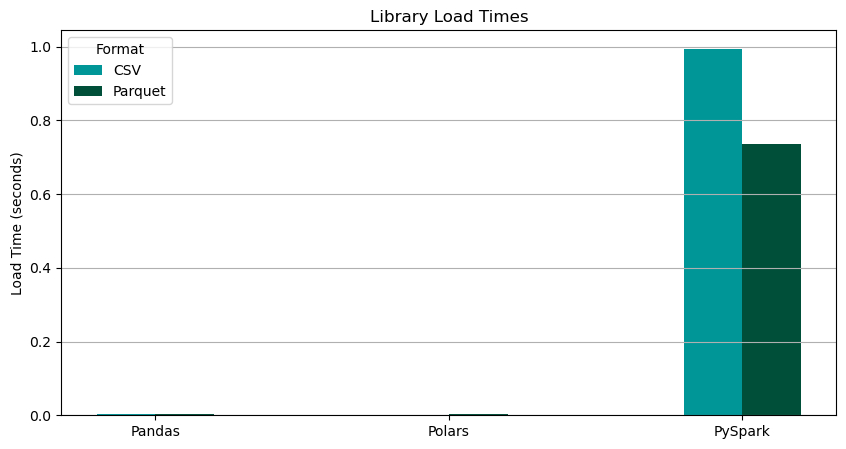

In [21]:
format_colors = {"CSV": "#009698","Parquet": "#004F39"}

libraries = df_load_times["Library"].unique()
formats = df_load_times["Format"].unique()
x = np.arange(len(libraries))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

for i, fmt in enumerate(formats):
    fmt_times = []
    for lib in libraries:
        val = df_load_times.loc[
            (df_load_times["Library"] == lib) & (df_load_times["Format"] == fmt),
            "Load_Time_Seconds"
        ]
        fmt_times.append(val.values[0] if len(val) > 0 else np.nan)
    ax.bar(x + i*width - width*(len(formats)-1)/2, fmt_times, width, label=fmt, color=format_colors[fmt])

ax.set_xticks(x)
ax.set_xticklabels(libraries)
ax.set_ylabel("Load Time (seconds)")
ax.set_title("Library Load Times")
ax.legend(title="Format")
ax.grid(axis="y")
plt.show()

   In the full chart, the PySpark load time are significantly higher than Pandas and Polars, to better visualize the comparison I create a zoomed-in chart that excludes PySpark.

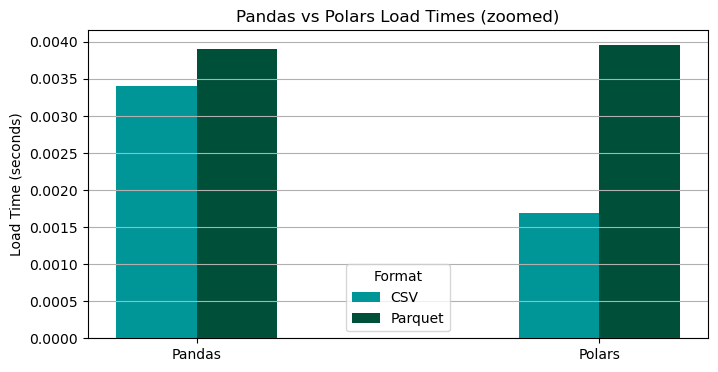

In [23]:
smaller_libs = ["Pandas", "Polars"]
x_sm = np.arange(len(smaller_libs))

fig, ax = plt.subplots(figsize=(8, 4))
for i, fmt in enumerate(formats):
    fmt_times = [
        df_load_times.loc[
            (df_load_times["Library"] == lib) & (df_load_times["Format"] == fmt),
            "Load_Time_Seconds"
        ].values[0]
        for lib in smaller_libs
    ]
    ax.bar(x_sm + i*width - width*(len(formats)-1)/2, fmt_times, width, label=fmt, color=format_colors[fmt])

ax.set_xticks(x_sm)
ax.set_xticklabels(smaller_libs)
ax.set_ylabel("Load Time (seconds)")
ax.set_title("Pandas vs Polars Load Times (zoomed)")
ax.legend(title="Format", loc="lower center")
ax.grid(axis="y")
plt.show()


### 2.1 Memory Usage Comparison

An estimation of the memory footprint of each library when loading the same datasets in both file formats.

PySpark memory usage could not be accurately measured in this environment. Spark manages memory across the JVM and executor processes, precise per-DataFrame memory measurements are non-trivial without cluster-level metrics. I chose to omit it.

In [ ]:
df_load_times = pd.DataFrame(results, columns=["Library", "Format", "Load_Time_Seconds"])

df_mem = pd.DataFrame({
    "Library": ["Pandas", "Pandas", "Polars", "Polars", "Spark", "Spark"],
    "Format": ["CSV", "Parquet"]*3,
    "Memory_MB": [
        df_pd_csv.memory_usage(deep=True).sum() / 1e6,
        df_pd_parquet.memory_usage(deep=True).sum() / 1e6,
        df_pl_csv.estimated_size() / 1e6,
        df_pl_parquet.estimated_size() / 1e6,
        None,
        None
    ]
})

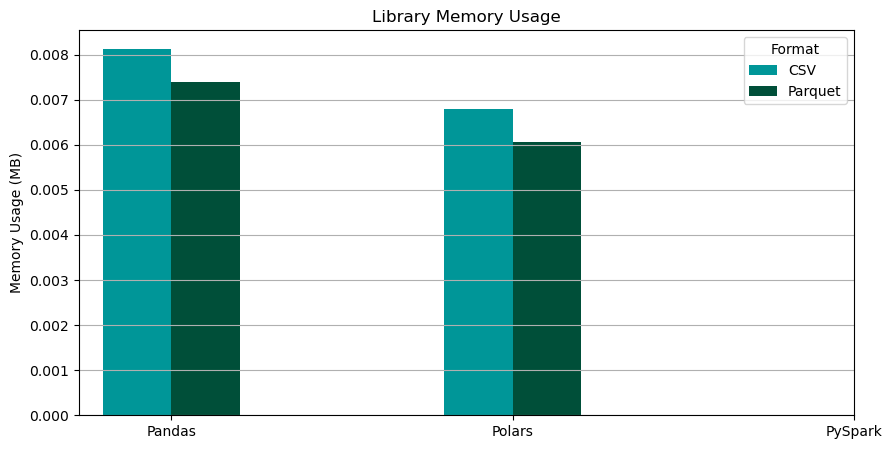

In [22]:

fig, ax = plt.subplots(figsize=(10, 5))

for i, fmt in enumerate(formats):
    fmt_mem = []
    for lib in libraries:
        val = df_mem.loc[
            (df_mem["Library"] == lib) & (df_mem["Format"] == fmt),
            "Memory_MB"
        ]
        fmt_mem.append(val.values[0] if len(val) > 0 else np.nan)
    ax.bar(x + i*width - width*(len(formats)-1)/2, fmt_mem, width, label=fmt, color=format_colors[fmt])

ax.set_xticks(x)
ax.set_xticklabels(libraries)
ax.set_ylabel("Memory Usage (MB)")
ax.set_title("Library Memory Usage")
ax.legend(title="Format", loc="upper right")

ax.grid(axis="y")
plt.show()

## 3. GroupBy Aggregation Benchmark

In [ ]:
data_sizes = [500_000, 3_000_000, 5_500_000, 8_000_000]
num_categories = 1000
df_time = pd.DataFrame(columns=["size", "pandas", "polars", "pyspark"])

In [ ]:
for size in data_sizes:
    
    df = pd.DataFrame({
        "id": np.arange(size),
        "category": np.random.choice([f"C{i}" for i in range(num_categories)], size),
        "value": np.random.randn(size)
    })

    start = time.time()
    mean_pd = df.groupby("category")["value"].mean()
    end = time.time()
    time_pd = end - start

    pl_df = pl.DataFrame(df)
    start = time.time()
    mean_pl = pl_df.group_by("category").agg(pl.col("value").mean())
    end = time.time()
    time_pl = end - start

    spark_df = spark.createDataFrame(df)
    start = time.time()
    mean_spark = spark_df.groupBy("category").avg("value").collect()
    end = time.time()
    time_spark = end - start

    df_time = pd.concat([
        df_time,
        pd.DataFrame({
            "size": [size],
            "pandas": [time_pd],
            "polars": [time_pl],
            "pyspark": [time_spark]
        })
    ], ignore_index=True)

26/02/01 22:45:21 WARN FileSystem: Cannot load filesystem
java.util.ServiceConfigurationError: org.apache.hadoop.fs.FileSystem: Provider org.apache.hadoop.fs.viewfs.ViewFileSystem could not be instantiated
	at java.base/java.util.ServiceLoader.fail(ServiceLoader.java:552)
	at java.base/java.util.ServiceLoader$ProviderImpl.newInstance(ServiceLoader.java:712)
	at java.base/java.util.ServiceLoader$ProviderImpl.get(ServiceLoader.java:672)
	at java.base/java.util.ServiceLoader$2.next(ServiceLoader.java:1256)
	at org.apache.hadoop.fs.FileSystem.loadFileSystems(FileSystem.java:3525)
	at org.apache.hadoop.fs.FileSystem.getFileSystemClass(FileSystem.java:3562)
	at org.apache.hadoop.fs.FsUrlStreamHandlerFactory.<init>(FsUrlStreamHandlerFactory.java:77)
	at org.apache.spark.sql.internal.SharedState$.liftedTree2$1(SharedState.scala:209)
	at org.apache.spark.sql.internal.SharedState$.org$apache$spark$sql$internal$SharedState$$setFsUrlStreamHandlerFactory(SharedState.scala:208)
	at org.apache.spark.

In [ ]:
df_pd = pd.DataFrame({
    "id": np.arange(data_sizes[-1]),
    "category": np.random.choice([f"C{i}" for i in range(num_categories)], data_sizes[-1]),
    "value": np.random.randn(data_sizes[-1])
})
df_pl = pl.DataFrame(df_pd)

Benchmark Times (seconds):
      size    pandas    polars   pyspark
0   500000  0.036735  0.038447  4.983719
1  3000000  0.095304   0.09867  2.704824
2  5500000    0.1627  0.159845  3.772244
3  8000000  0.268403  0.359242  8.011399


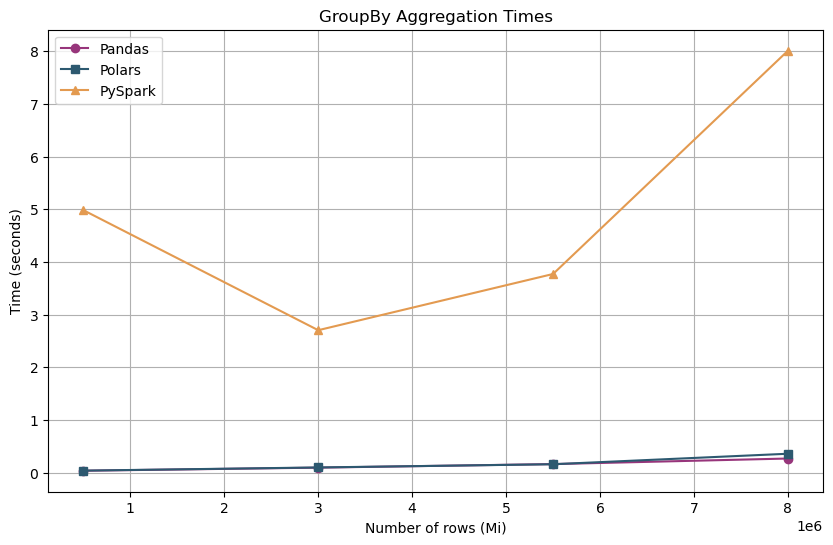

In [20]:
print("Benchmark Times (seconds):")
print(df_time)

plt.figure(figsize=(10, 6))
plt.plot(df_time["size"], df_time["pandas"], marker='o', label='Pandas', color="#97357B")
plt.plot(df_time["size"], df_time["polars"], marker='s', label='Polars', color="#2d5970")
plt.plot(df_time["size"], df_time["pyspark"], marker='^', label='PySpark', color="#e39a50")
plt.xlabel("Number of rows (Mi)")
plt.ylabel("Time (seconds)")
plt.title("GroupBy Aggregation Times")
plt.legend()
plt.grid(True)
plt.show()

plt.show()

   In this full chart, the PySpark groupBy aggregation times are also significantly higher than Pandas and Polars and a zoomed-in chart **excluding PySpark** was also created.

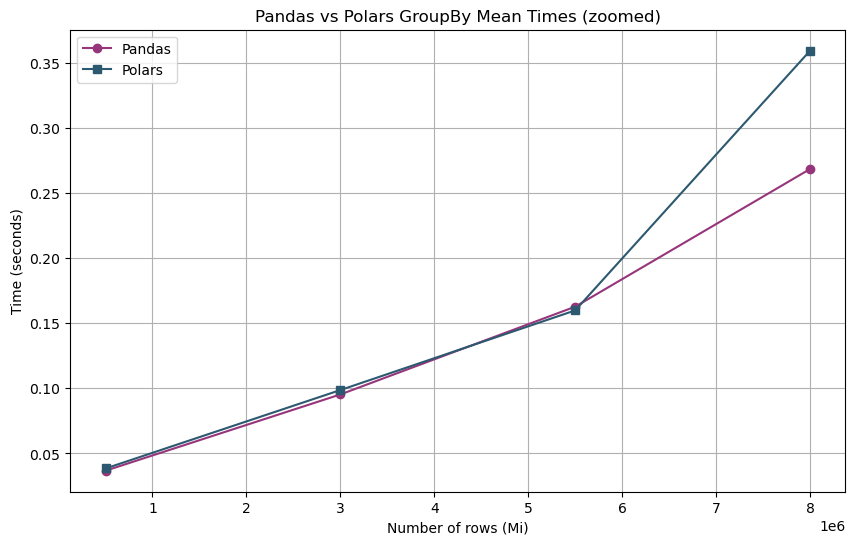

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(df_time["size"], df_time["pandas"], marker='o', label='Pandas', color="#97357B")
plt.plot(df_time["size"], df_time["polars"], marker='s', label='Polars', color="#2d5970")
plt.xlabel("Number of rows (Mi)")
plt.ylabel("Time (seconds)")
plt.title("Pandas vs Polars GroupBy Mean Times (zoomed)")
plt.legend()
plt.grid(True)
plt.show()

plt.show()

In [ ]:
spark.stop()